# Analyse — TicTacToe (vs Random)

TicTacToe 3×3 vs un opposant random. L'agent évalué est le **maximizing player**. L'évaluation joue 50% des parties en P0 (premier coup) et 50% en P1, pour neutraliser l'avantage du premier joueur.

**Reward attendu :** +1 victoire, 0 nul, -1 défaite (vs opposant random, équilibré P0/P1).

**Sources de données :**

| Fichier | Mode | Description |
|---|---|---|
| `results/tictactoe/{agent}/{run}/training_curve.csv` | TRAINING | reward par épisode pendant l'entraînement |
| `results/tictactoe/{agent}/{run}/metrics_reeval.csv` | INFERENCE | politique gelée, ε=0, balance P0/P1 si adversarial |
| `results/tictactoe/{agent}/{run}/metrics.csv` | INFERENCE (fallback) | éval pendant l'entraînement quand reeval absent |
| `results/tictactoe/{mcts,random_rollout}/budget_sweep_seed42/metrics.csv` | INFERENCE | sweep budget→score (planning) |

**Plan :**
1. Inventaire des runs
2. [TRAINING] Courbes d'apprentissage
3. [INFERENCE] Reward moyen au meilleur checkpoint
4. [INFERENCE] Reward par checkpoint (évolution)
5. [INFERENCE] Win / Draw / Loss au meilleur point (apprenants + planning)
6. [INFERENCE] Déséquilibre P0 vs P1
7. [INFERENCE] Longueur d'épisode
8. [INFERENCE] Temps d'inférence par coup
9. [INFERENCE] Reward aux checkpoints du syllabus (1k / 10k / 50k / 100k)
10. [INFERENCE] Best vs last checkpoint
11. [INFERENCE] Termination vs truncation
12. [PLANNING] MCTS et RandomRollout — sweep budget
13. [PARETO] Reward × latence (toutes méthodes)
14. Hyperparamètres
15. Synthèse — ranking final
16. Observations critiques


## 0. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd().parent / "notebooks"))
from _report_utils import (
    LEARNING_AGENTS, PLANNING_AGENTS, ALL_AGENTS, ADVERSARIAL_ENVS,
    discover_runs, load_eval_metrics, load_training_curve, load_planning_metrics,
    project_root, results_dir, agent_color, setup_plot_style,
)

setup_plot_style()
ENV_NAME  = "tictactoe"
ENV_TITLE = "TicTacToe (vs Random)"
EXPECTED_CHECKPOINTS = [1000, 10000, 50000, 100000]
IS_ADVERSARIAL = ENV_NAME in ADVERSARIAL_ENVS

print("Env :", ENV_NAME, "(", "adversarial" if IS_ADVERSARIAL else "solo", ")")
print("Project root :", project_root())


Env : tictactoe ( adversarial )
Project root : /Users/brandontchakaniyungeko/ESGI-dev/5IABD/T2/deep_reinforcement_learning/projet


In [2]:
learning_runs, planning_runs = discover_runs(ENV_NAME)
print(f"Learning runs : {len(learning_runs)}")
print(f"Planning runs : {len(planning_runs)}")

eval_frames = [load_eval_metrics(r) for r in learning_runs]
df_eval = pd.concat([f for f in eval_frames if not f.empty], ignore_index=True) if eval_frames else pd.DataFrame()

train_frames = [load_training_curve(r) for r in learning_runs]
df_train = pd.concat([f for f in train_frames if not f.empty], ignore_index=True) if train_frames else pd.DataFrame()

planning_frames = [load_planning_metrics(r) for r in planning_runs]
df_planning = pd.concat([f for f in planning_frames if not f.empty], ignore_index=True) if planning_frames else pd.DataFrame()

print(f"\nEval rows     : {len(df_eval)}")
print(f"Training rows : {len(df_train)}")
print(f"Planning rows : {len(df_planning)}")


Learning runs : 25
Planning runs : 2



Eval rows     : 122
Training rows : 4421000
Planning rows : 12


In [3]:
def best_per_agent_eval(df: pd.DataFrame, by: str = "mean_reward") -> pd.DataFrame:
    """For each agent, return the row with the highest score (`by`).
    Tie-break on lower mean_steps."""
    if df.empty or by not in df.columns:
        return df.iloc[0:0]
    sub = df.dropna(subset=[by]).sort_values([by, "mean_steps"], ascending=[False, True])
    return sub.groupby("agent", as_index=False).head(1)

def best_per_agent_planning(df: pd.DataFrame, by: str = "mean_reward") -> pd.DataFrame:
    """Best-budget row per planning agent."""
    if df.empty or by not in df.columns:
        return df.iloc[0:0]
    sub = df.dropna(subset=[by]).sort_values([by, "budget"], ascending=[False, True])
    return sub.groupby("agent", as_index=False).head(1)


## 1. Inventaire des runs

In [4]:
rows = []
for r in learning_runs:
    cfg = r["config"]
    rows.append({
        "type": "learning",
        "agent": r["agent"],
        "seed": r["seed"],
        "n_checkpoints": sum(1 for _ in r["run_dir"].glob("model_*.pt")),
        "num_episodes": cfg.get("training", {}).get("num_episodes", "-"),
        "run_name": r["run_name"][:75] + ("…" if len(r["run_name"]) > 75 else ""),
    })
for r in planning_runs:
    cfg = r["config"]
    rows.append({
        "type": "planning",
        "agent": r["agent"],
        "seed": r["seed"],
        "n_checkpoints": "-",
        "num_episodes": "-",
        "run_name": r["run_name"][:75],
    })

inv = pd.DataFrame(rows)
print(f"{len(inv)} runs au total")
inv


27 runs au total


,type,agent,seed,n_checkpoints,num_episodes,run_name
0,learning,ddqn,42,3,50000,batch_size64_buffer_capacity50000_epsilon_deca...
1,learning,ddqn_er,42,3,50000,batch_size64_buffer_capacity50000_epsilon_deca...
2,learning,ddqn_per,42,3,50000,batch_size64_buffer_capacity50000_epsilon_deca...
3,learning,dqn,42,3,50000,batch_size64_buffer_capacity50000_epsilon_deca...
4,learning,ppo,123,3,50000,batch_size32_clip_epsilon0.2_devicecpu_entropy...
5,learning,ppo,42,3,50000,batch_size32_clip_epsilon0.2_devicecpu_entropy...
6,learning,ppo,456,3,50000,batch_size32_clip_epsilon0.2_devicecpu_entropy...
7,learning,ppo,42,5,100000,batch_size32_clip_epsilon0.2_devicecpu_entropy...
8,learning,ppo,42,5,100000,batch_size32_clip_epsilon0.2_devicecpu_entropy...
9,learning,ppo,123,5,1000000,batch_size32_clip_epsilon0.2_devicecpu_entropy...


## 2. [TRAINING] Courbes d'apprentissage

Reward par épisode pendant l'entraînement (mode stochastique : ε-greedy pour Q-learning, sampling pour policy-gradient). Moyenne glissante sur 200 épisodes pour lisser le bruit. Une seed représentative par agent (seed 42 si disponible). Random est plat (pas d'apprentissage).

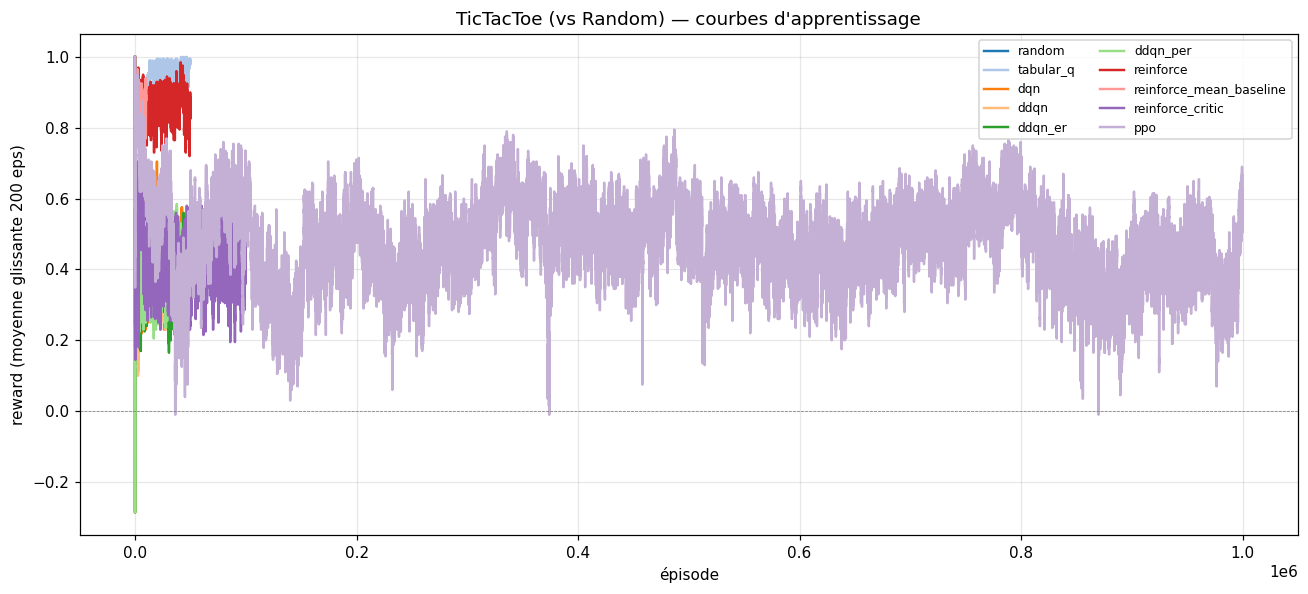

In [5]:
WINDOW = 200

if df_train.empty:
    print("Pas de courbes d'apprentissage.")
else:
    fig, ax = plt.subplots(figsize=(12, 5.5))
    for agent in [a for a in LEARNING_AGENTS if a in df_train["agent"].unique()]:
        sub = df_train[df_train["agent"] == agent]
        seeds_sorted = sorted(sub["seed"].unique(), key=lambda s: (s != 42, s))
        chosen = sub[sub["seed"] == seeds_sorted[0]]
        if chosen["run_name"].nunique() > 1:
            best_run = chosen.groupby("run_name").size().idxmax()
            chosen = chosen[chosen["run_name"] == best_run]
        chosen = chosen.sort_values("episode")
        if chosen.empty:
            continue
        smoothed = chosen["reward"].rolling(WINDOW, min_periods=1).mean()
        ax.plot(chosen["episode"], smoothed, label=agent, color=agent_color(agent), linewidth=1.6)
    ax.set_xlabel("épisode")
    ax.set_ylabel(f"reward (moyenne glissante {WINDOW} eps)")
    ax.set_title(f"{ENV_TITLE} — courbes d'apprentissage")
    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.legend(loc="best", fontsize=8, ncol=2, framealpha=0.85)
    plt.tight_layout()
    plt.show()


## 3. [INFERENCE] Reward moyen au meilleur checkpoint

Pour chaque agent apprenant, on prend le checkpoint qui maximise `mean_reward`. Pour MCTS / RandomRollout, on prend le résultat au plus gros budget. **Les planning agents sont inclus dans cette comparaison.**

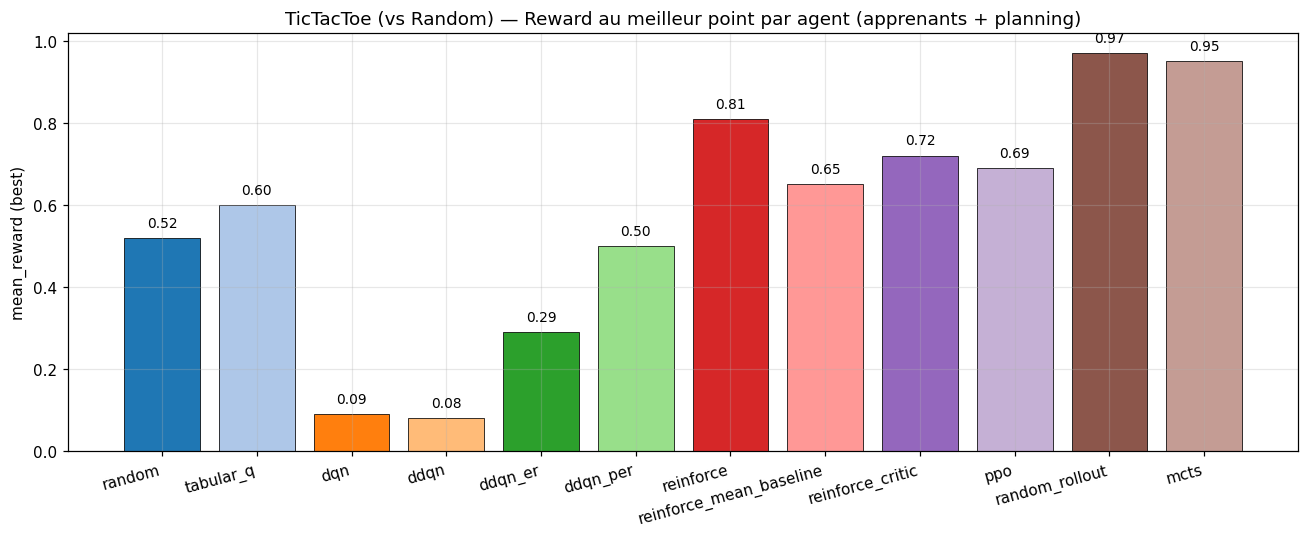

,mean_reward,type
random,0.5200,learning
tabular_q,0.6000,learning
dqn,0.0900,learning
ddqn,0.0800,learning
ddqn_er,0.2900,learning
ddqn_per,0.5000,learning
reinforce,0.8100,learning
reinforce_mean_baseline,0.6500,learning
reinforce_critic,0.7200,learning
ppo,0.6900,learning


In [6]:
best_learn = best_per_agent_eval(df_eval).set_index("agent")
best_plan = best_per_agent_planning(df_planning).set_index("agent")

all_idx = [a for a in ALL_AGENTS if a in best_learn.index] +           [a for a in PLANNING_AGENTS if a in best_plan.index]
seen = set()
all_idx = [a for a in all_idx if not (a in seen or seen.add(a))]

values = []
for a in all_idx:
    if a in best_learn.index and pd.notna(best_learn.loc[a, "mean_reward"]):
        values.append(best_learn.loc[a, "mean_reward"])
    elif a in best_plan.index:
        values.append(best_plan.loc[a, "mean_reward"])
    else:
        values.append(np.nan)

fig, ax = plt.subplots(figsize=(12, 5))
colors = [agent_color(a) for a in all_idx]
bars = ax.bar(all_idx, values, color=colors, edgecolor="black", linewidth=0.5)
for b, v in zip(bars, values):
    if pd.notna(v):
        ax.text(b.get_x() + b.get_width()/2, v + 0.02 if v >= 0 else v - 0.05,
                f"{v:.2f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("mean_reward (best)")
ax.set_title(f"{ENV_TITLE} — Reward au meilleur point par agent (apprenants + planning)")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

# Tableau récapitulatif
rec = pd.DataFrame({"mean_reward": values, "type": ["planning" if a in PLANNING_AGENTS else "learning" for a in all_idx]}, index=all_idx)
display(rec.round(3))


## 4. [INFERENCE] Évolution du reward par checkpoint

Un point par checkpoint, courbe par agent. Permet de détecter les agents qui régressent en fin d'entraînement.

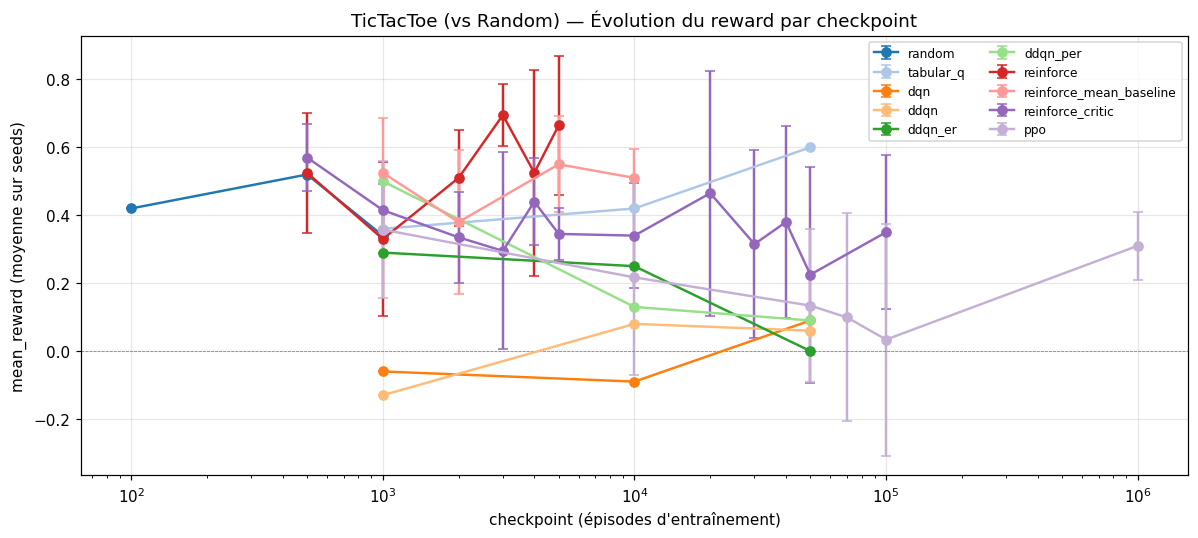

In [7]:
if df_eval.empty:
    print("Pas de données d'évaluation.")
else:
    fig, ax = plt.subplots(figsize=(11, 5))
    for agent in [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]:
        sub = df_eval[df_eval["agent"] == agent].dropna(subset=["mean_reward"])
        if sub.empty:
            continue
        agg = sub.groupby("checkpoint", as_index=False).agg(
            mean_reward=("mean_reward", "mean"),
            std=("mean_reward", "std"),
        ).fillna(0)
        ax.errorbar(agg["checkpoint"], agg["mean_reward"], yerr=agg["std"],
                    label=agent, color=agent_color(agent), marker="o",
                    capsize=3, linewidth=1.6)
    ax.set_xscale("log")
    ax.set_xlabel("checkpoint (épisodes d'entraînement)")
    ax.set_ylabel("mean_reward (moyenne sur seeds)")
    ax.set_title(f"{ENV_TITLE} — Évolution du reward par checkpoint")
    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.legend(loc="best", fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


## 5. [INFERENCE] Win / Draw / Loss au meilleur point

Décomposition victoire / nul / défaite (P0+P1 combiné) au meilleur checkpoint pour les apprenants et au meilleur budget pour les planning agents. Les agents sans split adversarial (`reinforce_critic`, `reinforce_mean_baseline` quand seul `metrics.csv` existe) sont absents de ce graphe — ils n'ont pas été re-évalués.

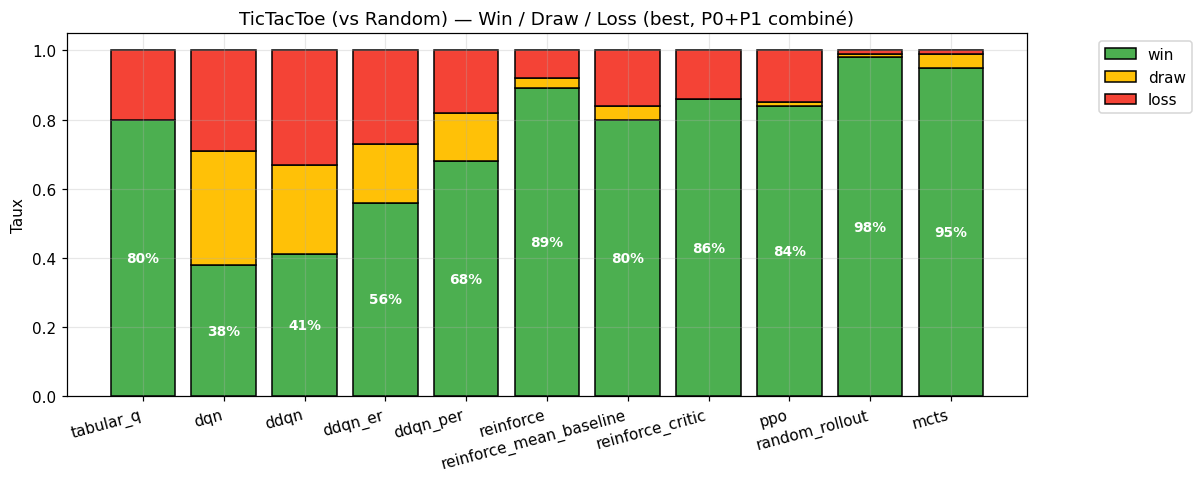

,win_rate,draw_rate,loss_rate,type
agent,,,,
tabular_q,0.8000,0.0000,0.2000,learning
dqn,0.3800,0.3300,0.2900,learning
ddqn,0.4100,0.2600,0.3300,learning
ddqn_er,0.5600,0.1700,0.2700,learning
ddqn_per,0.6800,0.1400,0.1800,learning
reinforce,0.8900,0.0300,0.0800,learning
reinforce_mean_baseline,0.8000,0.0400,0.1600,learning
reinforce_critic,0.8600,0.0000,0.1400,learning
ppo,0.8400,0.0100,0.1500,learning


In [8]:
rows = []
for a in LEARNING_AGENTS:
    if a not in df_eval["agent"].unique():
        continue
    sub = df_eval[df_eval["agent"] == a].dropna(subset=["win_rate"])
    if sub.empty:
        continue
    best = sub.sort_values("win_rate", ascending=False).iloc[0]
    rows.append({"agent": a, "win_rate": best["win_rate"],
                 "draw_rate": best.get("draw_rate", 0),
                 "loss_rate": best.get("loss_rate", 0),
                 "type": "learning"})

for a in PLANNING_AGENTS:
    if df_planning.empty or a not in df_planning["agent"].unique():
        continue
    sub = df_planning[df_planning["agent"] == a].dropna(subset=["win_rate"])
    if sub.empty:
        continue
    best = sub.sort_values("win_rate", ascending=False).iloc[0]
    rows.append({"agent": a, "win_rate": best["win_rate"],
                 "draw_rate": best.get("draw_rate", 0),
                 "loss_rate": best.get("loss_rate", 0),
                 "type": "planning"})

if not rows:
    print("Pas de données win_rate disponibles.")
else:
    df_wdl = pd.DataFrame(rows).set_index("agent")
    df_wdl = df_wdl.reindex([a for a in ALL_AGENTS if a in df_wdl.index])
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.bar(df_wdl.index, df_wdl["win_rate"], color="#4CAF50", label="win", edgecolor="black")
    ax.bar(df_wdl.index, df_wdl["draw_rate"].fillna(0), bottom=df_wdl["win_rate"],
           color="#FFC107", label="draw", edgecolor="black")
    ax.bar(df_wdl.index, df_wdl["loss_rate"].fillna(0),
           bottom=df_wdl["win_rate"] + df_wdl["draw_rate"].fillna(0),
           color="#F44336", label="loss", edgecolor="black")
    for i, agent in enumerate(df_wdl.index):
        wr = df_wdl.loc[agent, "win_rate"]
        if pd.notna(wr) and wr > 0.05:
            ax.text(i, wr/2, f"{wr:.0%}", ha="center", va="center",
                    color="white", fontsize=9, fontweight="bold")
    ax.set_ylabel("Taux")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{ENV_TITLE} — Win / Draw / Loss (best, P0+P1 combiné)")
    ax.legend(loc="upper right", bbox_to_anchor=(1.18, 1))
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()
    display(df_wdl[["win_rate", "draw_rate", "loss_rate", "type"]].round(3))


## 6. [INFERENCE] Déséquilibre P0 vs P1

Quand l'agent joue **en premier (P0)** vs **en second (P1)**, les win_rates devraient être proches si la policy est robuste. Un fort écart indique :
- soit un avantage structurel du premier joueur (TicTacToe favorise P0),
- soit un agent qui a sur-appris une seule perspective.

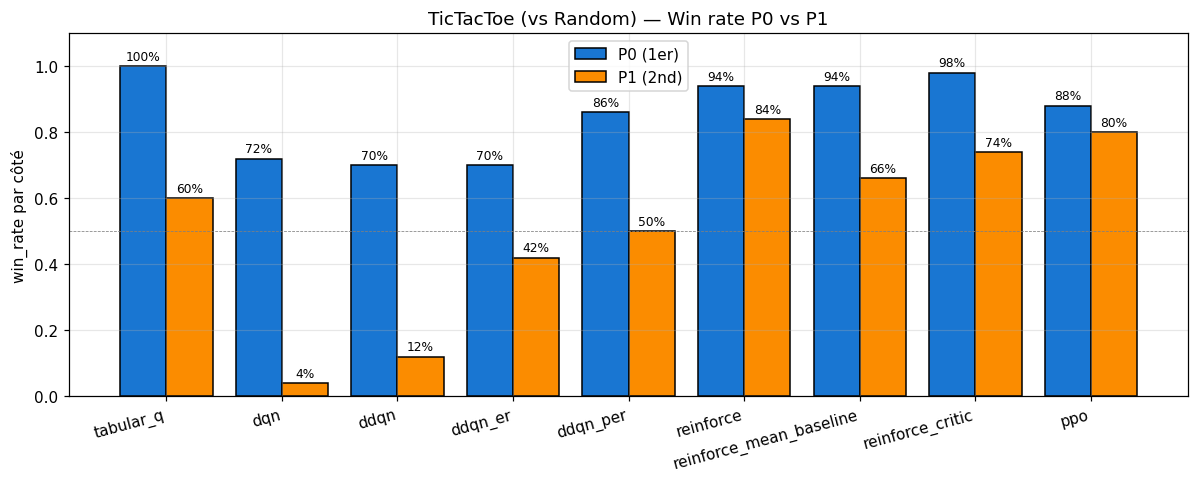

,win_rate_p0,win_rate_p1,p0_minus_p1
agent,,,
tabular_q,1.0000,0.6000,0.4000
dqn,0.7200,0.0400,0.6800
ddqn,0.7000,0.1200,0.5800
ddqn_er,0.7000,0.4200,0.2800
ddqn_per,0.8600,0.5000,0.3600
reinforce,0.9400,0.8400,0.1000
reinforce_mean_baseline,0.9400,0.6600,0.2800
reinforce_critic,0.9800,0.7400,0.2400
ppo,0.8800,0.8000,0.0800


In [9]:
sub_adv = df_eval.dropna(subset=["win_rate_p0", "win_rate_p1"])
if sub_adv.empty:
    print("Pas de split P0/P1 disponible (réévaluation manquante pour les agents non-DQN).")
else:
    best = sub_adv.sort_values("win_rate", ascending=False).groupby("agent", as_index=False).head(1)
    best = best.set_index("agent")
    best = best.reindex([a for a in LEARNING_AGENTS if a in best.index])
    x = np.arange(len(best))
    w = 0.4
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.bar(x - w/2, best["win_rate_p0"], w, label="P0 (1er)", color="#1976D2", edgecolor="black")
    ax.bar(x + w/2, best["win_rate_p1"], w, label="P1 (2nd)", color="#FB8C00", edgecolor="black")
    for i, a in enumerate(best.index):
        for off, c in [(-w/2, "win_rate_p0"), (w/2, "win_rate_p1")]:
            v = best.loc[a, c]
            if pd.notna(v):
                ax.text(i + off, v + 0.01, f"{v:.0%}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(best.index, rotation=15, ha="right")
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color="gray", lw=0.5, ls="--")
    ax.legend()
    ax.set_ylabel("win_rate par côté")
    ax.set_title(f"{ENV_TITLE} — Win rate P0 vs P1")
    plt.tight_layout()
    plt.show()
    delta = (best["win_rate_p0"] - best["win_rate_p1"]).rename("p0_minus_p1")
    display(pd.concat([best[["win_rate_p0", "win_rate_p1"]], delta], axis=1).round(3))


## 7. [INFERENCE] Longueur d'épisode (steps)

Combien de steps prend une partie en moyenne. Une longueur proche de `max_steps=10000` indique une **truncation** (politique bloquée). Les planning agents sont inclus à leur meilleur budget.

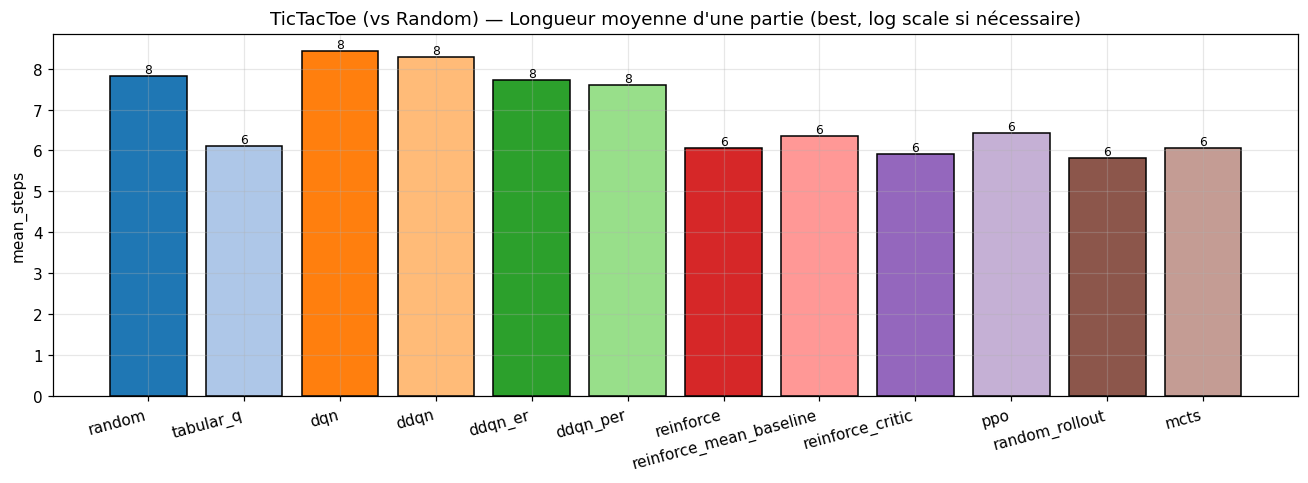

,mean_steps,type
agent,,
random,7.8000,learning
tabular_q,6.1000,learning
dqn,8.4000,learning
ddqn,8.3000,learning
ddqn_er,7.7000,learning
ddqn_per,7.6000,learning
reinforce,6.1000,learning
reinforce_mean_baseline,6.4000,learning
reinforce_critic,5.9000,learning


In [10]:
rows = []
for a in LEARNING_AGENTS:
    if a not in df_eval["agent"].unique():
        continue
    sub = df_eval[df_eval["agent"] == a].dropna(subset=["mean_reward", "mean_steps"])
    if sub.empty:
        continue
    best = sub.sort_values("mean_reward", ascending=False).iloc[0]
    rows.append({"agent": a, "mean_steps": best["mean_steps"], "type": "learning"})

for a in PLANNING_AGENTS:
    if df_planning.empty or a not in df_planning["agent"].unique():
        continue
    sub = df_planning[df_planning["agent"] == a].dropna(subset=["mean_reward", "mean_steps"])
    if sub.empty:
        continue
    best = sub.sort_values("mean_reward", ascending=False).iloc[0]
    rows.append({"agent": a, "mean_steps": best["mean_steps"], "type": "planning"})

if not rows:
    print("Pas de données mean_steps.")
else:
    df_steps = pd.DataFrame(rows).set_index("agent")
    df_steps = df_steps.reindex([a for a in ALL_AGENTS if a in df_steps.index])
    fig, ax = plt.subplots(figsize=(12, 4.5))
    bars = ax.bar(df_steps.index, df_steps["mean_steps"],
                  color=[agent_color(a) for a in df_steps.index], edgecolor="black")
    for b, v in zip(bars, df_steps["mean_steps"]):
        ax.text(b.get_x() + b.get_width()/2, v, f"{v:.0f}",
                ha="center", va="bottom", fontsize=8)
    ax.set_ylabel("mean_steps")
    ax.set_title(f"{ENV_TITLE} — Longueur moyenne d'une partie (best, log scale si nécessaire)")
    if df_steps["mean_steps"].max() > 1000:
        ax.set_yscale("log")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()
    display(df_steps.round(1))


## 8. [INFERENCE] Temps d'inférence par coup (ms)

Métrique demandée par le syllabus. Mesurée côté CPU dans `agent.act(state)`. Échelle log car les ordres de grandeur varient (`random` ≈ 1 µs, `mcts` budget=1000 ≈ 100 ms).

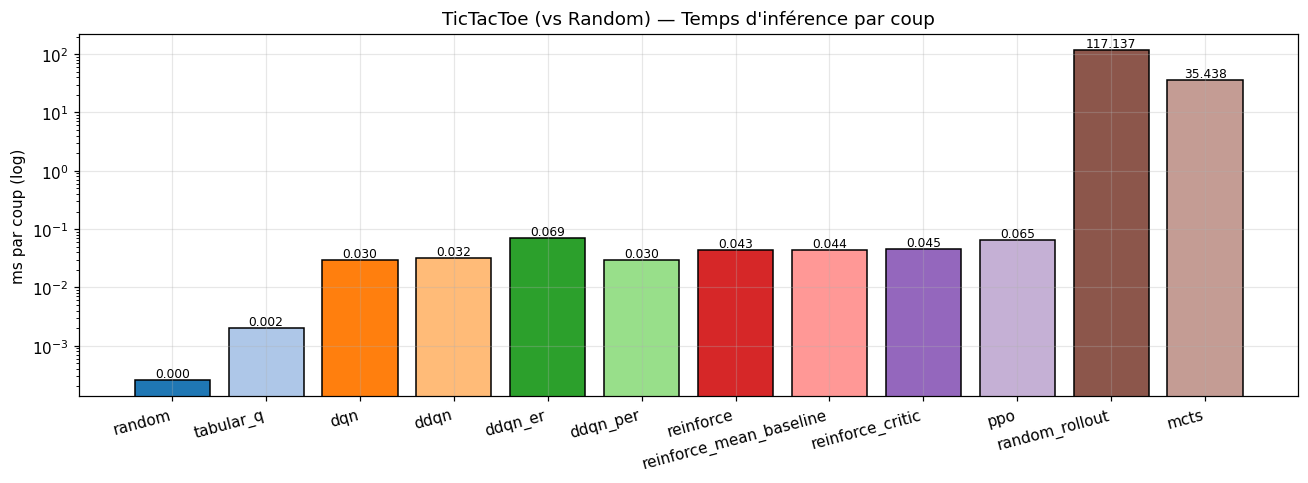

,mean_action_time_ms,type
agent,,
random,0.0003,learning
tabular_q,0.0020,learning
dqn,0.0300,learning
ddqn,0.0320,learning
ddqn_er,0.0690,learning
ddqn_per,0.0300,learning
reinforce,0.0430,learning
reinforce_mean_baseline,0.0440,learning
reinforce_critic,0.0450,learning


In [11]:
rows = []
for a in LEARNING_AGENTS:
    if a not in df_eval["agent"].unique():
        continue
    sub = df_eval[df_eval["agent"] == a].dropna(subset=["mean_reward", "mean_action_time_ms"])
    if sub.empty:
        continue
    best = sub.sort_values("mean_reward", ascending=False).iloc[0]
    rows.append({"agent": a, "mean_action_time_ms": best["mean_action_time_ms"], "type": "learning"})

for a in PLANNING_AGENTS:
    if df_planning.empty or a not in df_planning["agent"].unique():
        continue
    sub = df_planning[df_planning["agent"] == a].dropna(subset=["mean_reward", "mean_action_time_ms"])
    if sub.empty:
        continue
    best = sub.sort_values("mean_reward", ascending=False).iloc[0]
    rows.append({"agent": a, "mean_action_time_ms": best["mean_action_time_ms"], "type": "planning"})

if not rows:
    print("Pas de données temps.")
else:
    df_t = pd.DataFrame(rows).set_index("agent")
    df_t = df_t.reindex([a for a in ALL_AGENTS if a in df_t.index])
    fig, ax = plt.subplots(figsize=(12, 4.5))
    bars = ax.bar(df_t.index, df_t["mean_action_time_ms"],
                  color=[agent_color(a) for a in df_t.index], edgecolor="black")
    for b, v in zip(bars, df_t["mean_action_time_ms"]):
        ax.text(b.get_x() + b.get_width()/2, v, f"{v:.3f}",
                ha="center", va="bottom", fontsize=8)
    ax.set_yscale("log")
    ax.set_ylabel("ms par coup (log)")
    ax.set_title(f"{ENV_TITLE} — Temps d'inférence par coup")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()
    display(df_t.round(4))


## 9. [INFERENCE] Reward aux checkpoints du syllabus

Format direct du syllabus : score moyen de la policy gelée évaluée à 1k, 10k, 50k, 100k parties d'entraînement.

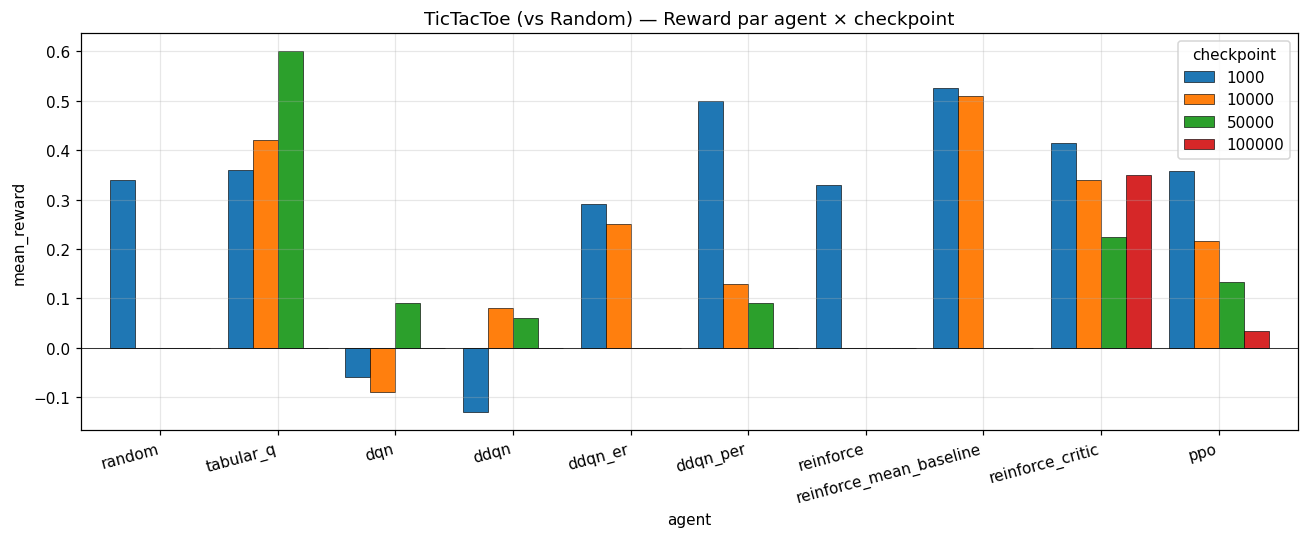

checkpoint,1000,10000,50000,100000
agent,,,,
random,0.3400,NaN,NaN,NaN
tabular_q,0.3600,0.4200,0.6000,NaN
dqn,-0.0600,-0.0900,0.0900,NaN
ddqn,-0.1300,0.0800,0.0600,NaN
ddqn_er,0.2900,0.2500,0.0000,NaN
ddqn_per,0.5000,0.1300,0.0900,NaN
reinforce,0.3300,NaN,NaN,NaN
reinforce_mean_baseline,0.5250,0.5100,NaN,NaN
reinforce_critic,0.4150,0.3400,0.2250,0.3500


In [12]:
checkpoints_target = [1000, 10000, 50000, 100000]
sub = df_eval[df_eval["checkpoint"].isin(checkpoints_target)]
if sub.empty:
    print("Pas de checkpoints dans la liste cible.")
else:
    pivot = sub.pivot_table(index="agent", columns="checkpoint", values="mean_reward", aggfunc="mean")
    pivot = pivot.reindex([a for a in LEARNING_AGENTS if a in pivot.index],
                          columns=[c for c in checkpoints_target if c in pivot.columns])
    fig, ax = plt.subplots(figsize=(12, 5))
    pivot.plot(kind="bar", ax=ax, edgecolor="black", linewidth=0.4, width=0.85)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_ylabel("mean_reward")
    ax.set_title(f"{ENV_TITLE} — Reward par agent × checkpoint")
    plt.xticks(rotation=15, ha="right")
    plt.legend(title="checkpoint")
    plt.tight_layout()
    plt.show()
    display(pivot.round(3))


## 10. [INFERENCE] Best vs last checkpoint — détection de régression

« Plus d'épisodes ≠ meilleur résultat ». Pour chaque agent, on compare le checkpoint qui a la meilleure performance vs le dernier checkpoint sauvegardé. Un écart > 0 signifie que l'agent a régressé en fin d'entraînement.

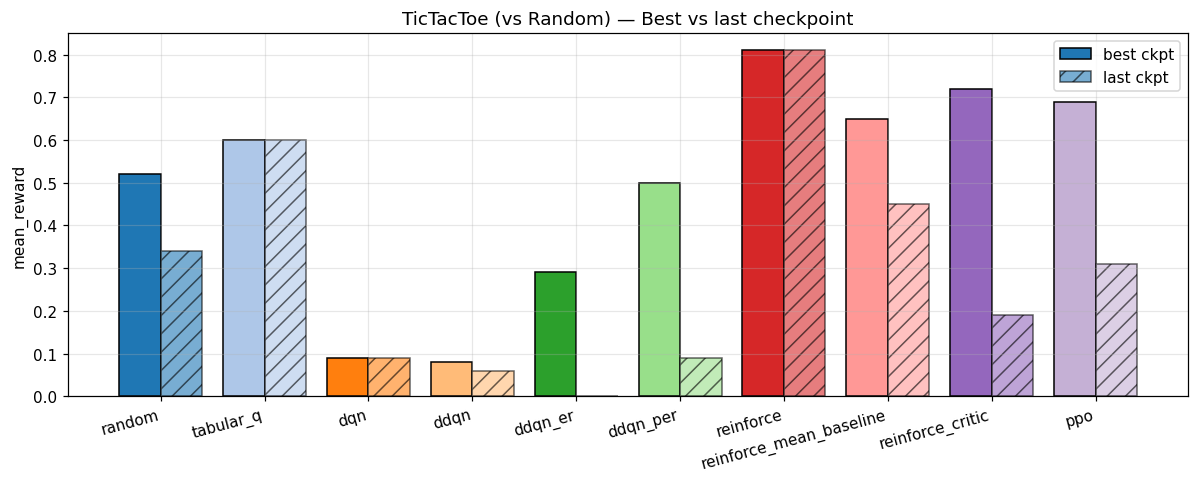

,best_ckpt,best_reward,last_ckpt,last_reward,regression
agent,,,,,
random,500,0.5200,1000,0.3400,YES
tabular_q,50000,0.6000,50000,0.6000,no
dqn,50000,0.0900,50000,0.0900,no
ddqn,10000,0.0800,50000,0.0600,YES
ddqn_er,1000,0.2900,50000,0.0000,YES
ddqn_per,1000,0.5000,50000,0.0900,YES
reinforce,5000,0.8100,5000,0.8100,no
reinforce_mean_baseline,5000,0.6500,10000,0.4500,YES
reinforce_critic,20000,0.7200,100000,0.1900,YES


In [13]:
rows = []
for a in [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]:
    sub = df_eval[df_eval["agent"] == a].dropna(subset=["mean_reward"])
    if sub.empty:
        continue
    best = sub.loc[sub["mean_reward"].idxmax()]
    last = sub.sort_values("checkpoint").iloc[-1]
    rows.append({
        "agent": a,
        "best_ckpt": int(best["checkpoint"]),
        "best_reward": best["mean_reward"],
        "last_ckpt": int(last["checkpoint"]),
        "last_reward": last["mean_reward"],
        "regression": "YES" if best["mean_reward"] > last["mean_reward"] + 1e-3 else "no",
    })
if not rows:
    print("Pas de données pour la comparaison.")
else:
    df_reg = pd.DataFrame(rows).set_index("agent")
    df_reg = df_reg.reindex([a for a in LEARNING_AGENTS if a in df_reg.index])
    fig, ax = plt.subplots(figsize=(11, 4.5))
    x = np.arange(len(df_reg))
    w = 0.4
    ax.bar(x - w/2, df_reg["best_reward"], w, label="best ckpt",
           color=[agent_color(a) for a in df_reg.index], edgecolor="black")
    ax.bar(x + w/2, df_reg["last_reward"], w, label="last ckpt", alpha=0.6,
           color=[agent_color(a) for a in df_reg.index], edgecolor="black", hatch="//")
    ax.set_xticks(x)
    ax.set_xticklabels(df_reg.index, rotation=15, ha="right")
    ax.axhline(0, color="black", lw=0.5)
    ax.set_ylabel("mean_reward")
    ax.set_title(f"{ENV_TITLE} — Best vs last checkpoint")
    ax.legend()
    plt.tight_layout()
    plt.show()
    display(df_reg)


## 11. [INFERENCE] Termination vs truncation

`terminated` : la partie s'est finie proprement (`done=True`) avant `max_steps=10000`. `truncated` : politique bloquée → l'évaluateur a dû couper. Un agent à `mean_reward = 0` peut être en vrai nul OU bloqué — cette section les distingue.

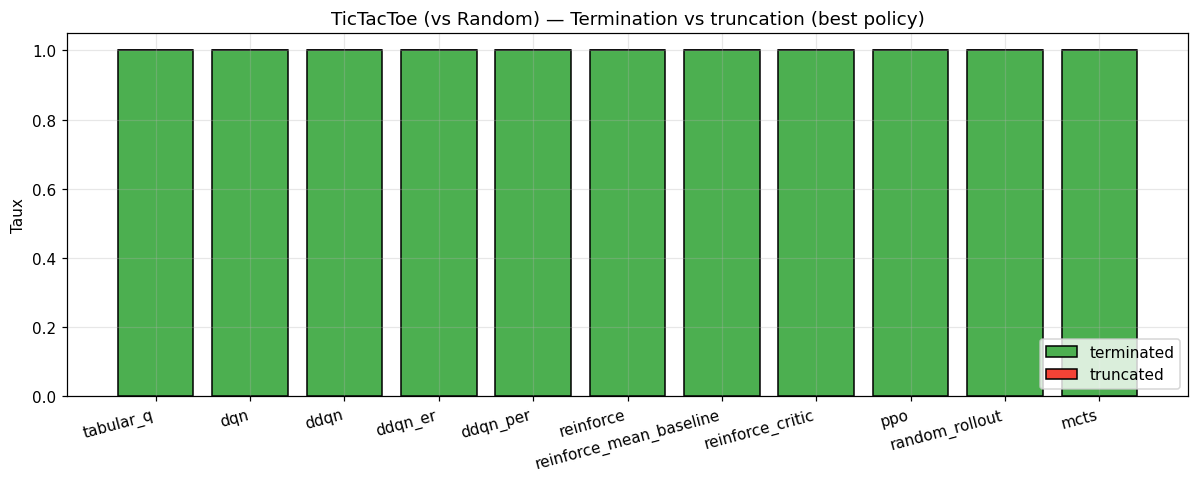

,termination_rate,truncation_rate,type
agent,,,
tabular_q,1.0000,0.0000,learning
dqn,1.0000,0.0000,learning
ddqn,1.0000,0.0000,learning
ddqn_er,1.0000,0.0000,learning
ddqn_per,1.0000,0.0000,learning
reinforce,1.0000,0.0000,learning
reinforce_mean_baseline,1.0000,0.0000,learning
reinforce_critic,1.0000,0.0000,learning
ppo,1.0000,0.0000,learning


In [14]:
rows = []
for a in [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]:
    sub = df_eval[df_eval["agent"] == a].dropna(subset=["termination_rate", "mean_reward"])
    if sub.empty:
        continue
    best = sub.sort_values("mean_reward", ascending=False).iloc[0]
    rows.append({"agent": a, "termination_rate": best["termination_rate"],
                 "truncation_rate": 1.0 - best["termination_rate"], "type": "learning"})

for a in [a for a in PLANNING_AGENTS if not df_planning.empty and a in df_planning["agent"].unique()]:
    sub = df_planning[df_planning["agent"] == a].dropna(subset=["termination_rate", "mean_reward"])
    if sub.empty:
        continue
    best = sub.sort_values("mean_reward", ascending=False).iloc[0]
    rows.append({"agent": a, "termination_rate": best["termination_rate"],
                 "truncation_rate": 1.0 - best["termination_rate"], "type": "planning"})

if not rows:
    print("Pas de données termination.")
else:
    df_term = pd.DataFrame(rows).set_index("agent")
    df_term = df_term.reindex([a for a in ALL_AGENTS if a in df_term.index])
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.bar(df_term.index, df_term["termination_rate"], color="#4CAF50",
           label="terminated", edgecolor="black")
    ax.bar(df_term.index, df_term["truncation_rate"],
           bottom=df_term["termination_rate"], color="#F44336",
           label="truncated", edgecolor="black")
    ax.set_ylabel("Taux")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{ENV_TITLE} — Termination vs truncation (best policy)")
    ax.legend(loc="lower right")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()
    display(df_term.round(3))


## 12. [PLANNING] MCTS et RandomRollout — sweep budget

Sweep produit par `scripts/evaluate_planning_agents.py`. Pour chaque budget, on évalue la performance et le coût en temps. La courbe gauche montre la qualité, la droite le coût (temps × budget).

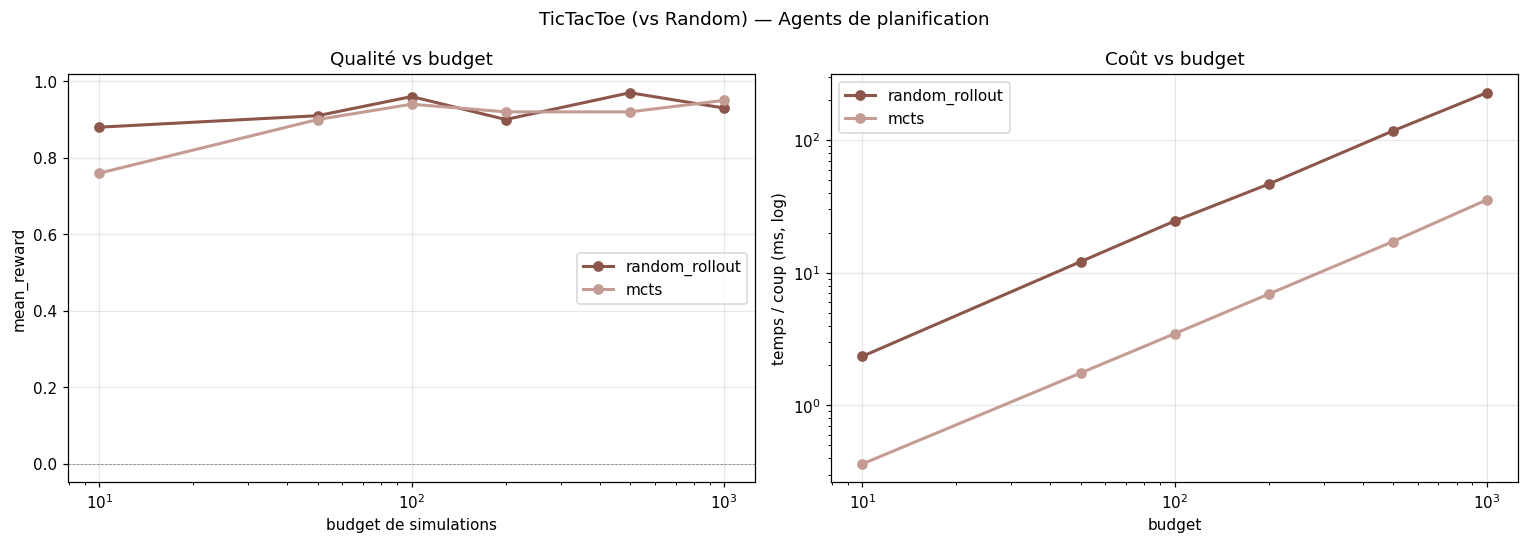

,agent,budget,mean_reward,win_rate,mean_steps,mean_action_time_ms
0,mcts,10,0.7600,0.8500,6.4300,0.3620
1,mcts,50,0.9000,0.9200,6.2400,1.7540
2,mcts,100,0.9400,0.9500,6.1400,3.4700
3,mcts,200,0.9200,0.9400,6.1900,6.9000
4,mcts,500,0.9200,0.9200,6.2500,17.1730
5,mcts,1000,0.9500,0.9500,6.0700,35.4380
6,random_rollout,10,0.8800,0.9100,6.2300,2.3440
7,random_rollout,50,0.9100,0.9300,6.0100,12.1140
8,random_rollout,100,0.9600,0.9700,5.8800,24.5280
9,random_rollout,200,0.9000,0.9000,6.1400,46.5470


In [15]:
if df_planning.empty:
    print("Pas de données planning. Lance :")
    print(f"  uv run scripts/evaluate_planning_agents.py configs_done/mcts/{ENV_NAME}.yaml")
    print(f"  uv run scripts/evaluate_planning_agents.py configs_done/random_rollout/{ENV_NAME}.yaml")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for a in [a for a in PLANNING_AGENTS if a in df_planning["agent"].unique()]:
        sub = df_planning[df_planning["agent"] == a].sort_values("budget")
        axes[0].plot(sub["budget"], sub["mean_reward"], marker="o",
                     label=a, color=agent_color(a), linewidth=2)
        axes[1].plot(sub["budget"], sub["mean_action_time_ms"], marker="o",
                     label=a, color=agent_color(a), linewidth=2)
    axes[0].set_xscale("log")
    axes[0].set_xlabel("budget de simulations")
    axes[0].set_ylabel("mean_reward")
    axes[0].set_title("Qualité vs budget")
    axes[0].axhline(0, color="gray", lw=0.5, ls="--")
    axes[0].legend()
    axes[1].set_xscale("log"); axes[1].set_yscale("log")
    axes[1].set_xlabel("budget"); axes[1].set_ylabel("temps / coup (ms, log)")
    axes[1].set_title("Coût vs budget")
    axes[1].legend()
    plt.suptitle(f"{ENV_TITLE} — Agents de planification")
    plt.tight_layout()
    plt.show()
    cols = ["agent", "budget", "mean_reward", "mean_steps", "mean_action_time_ms"]
    if "win_rate" in df_planning.columns:
        cols.insert(3, "win_rate")
    display(df_planning[cols].sort_values(["agent", "budget"]).reset_index(drop=True))


## 13. [PARETO] Reward × latence — toutes les méthodes

Chaque point = une (agent, configuration). On cherche le coin **haut-gauche** : reward élevé, temps faible. Les triangles = planning agents.

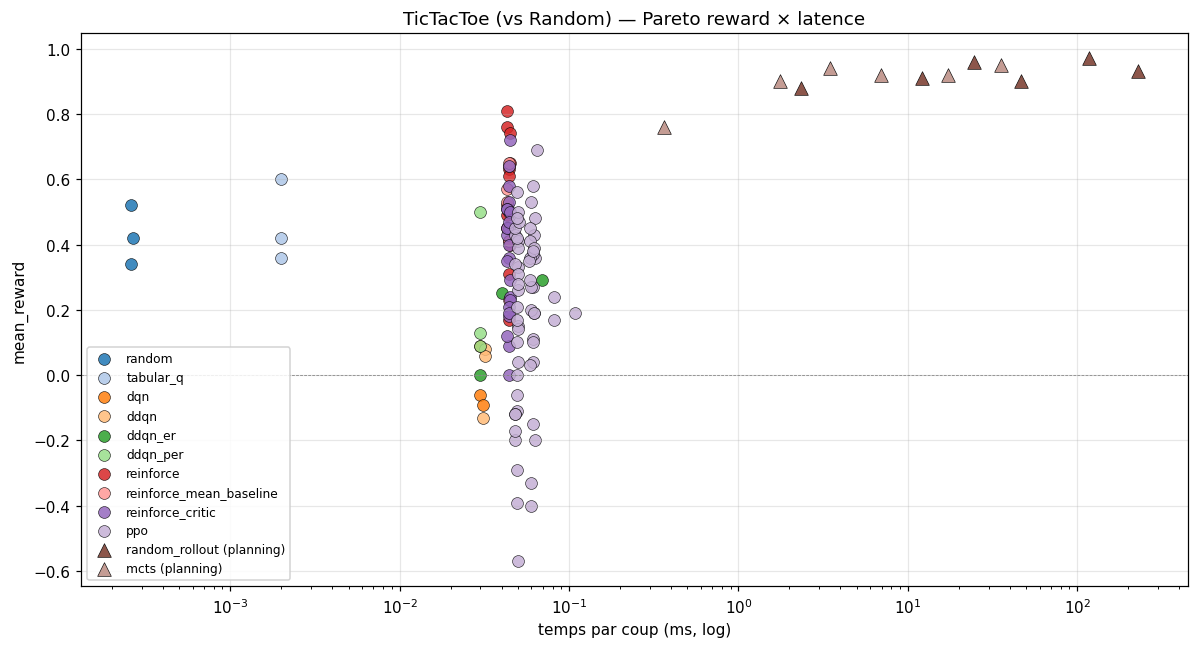

In [16]:
fig, ax = plt.subplots(figsize=(11, 6))

if not df_eval.empty:
    for a in [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]:
        sub = df_eval[df_eval["agent"] == a].dropna(subset=["mean_reward", "mean_action_time_ms"])
        if sub.empty:
            continue
        ax.scatter(sub["mean_action_time_ms"], sub["mean_reward"],
                   s=60, color=agent_color(a), edgecolor="black", linewidth=0.4,
                   label=f"{a}", alpha=0.85)

if not df_planning.empty:
    for a in [a for a in PLANNING_AGENTS if a in df_planning["agent"].unique()]:
        sub = df_planning[df_planning["agent"] == a].dropna(subset=["mean_reward", "mean_action_time_ms"])
        if sub.empty:
            continue
        ax.scatter(sub["mean_action_time_ms"], sub["mean_reward"],
                   s=80, color=agent_color(a), marker="^", edgecolor="black",
                   linewidth=0.4, label=f"{a} (planning)")

ax.set_xscale("log")
ax.set_xlabel("temps par coup (ms, log)")
ax.set_ylabel("mean_reward")
ax.set_title(f"{ENV_TITLE} — Pareto reward × latence")
ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.legend(loc="best", fontsize=8, framealpha=0.85)
plt.tight_layout()
plt.show()


## 14. Hyperparamètres

Snapshot tels qu'utilisés pendant l'entraînement (lus depuis `results/{env}/{agent}/{run}/config.yaml`).

In [17]:
hp_rows = []
for r in learning_runs + planning_runs:
    cfg = r["config"]
    flat = {"agent": r["agent"], "seed": cfg.get("seed", "")}
    for k, v in (cfg.get("agent_params") or {}).items():
        flat[f"ap.{k}"] = v
    if "training" in cfg:
        flat["num_episodes"] = cfg["training"].get("num_episodes", "")
    if "budgets" in cfg:
        flat["budgets"] = str(cfg["budgets"])
    hp_rows.append(flat)
hp = pd.DataFrame(hp_rows).set_index("agent")
hp


,seed,ap.batch_size,ap.buffer_capacity,ap.epsilon_decay_steps,ap.epsilon_end,ap.epsilon_start,ap.gamma,ap.hidden_layers,ap.lr,ap.target_update_freq,...,ap.gae_lambda,ap.max_grad_norm,ap.n_epochs,ap.value_coef,ap.critic_lr,ap.c_uct,ap.max_rollout_depth,ap.n_simulations,budgets,ap.n_rollouts_per_action
agent,,,,,,,,,,,,,,,,,,,,,
ddqn,42,64.0000,50000.0000,50000.0000,0.0500,1.0000,0.9900,"[128, 128]",0.0010,200.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ddqn_er,42,64.0000,50000.0000,50000.0000,0.0500,1.0000,0.9900,"[128, 128]",0.0010,200.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ddqn_per,42,64.0000,50000.0000,50000.0000,0.0500,1.0000,0.9900,"[128, 128]",0.0005,200.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dqn,42,64.0000,50000.0000,50000.0000,0.0500,1.0000,0.9900,"[128, 128]",0.0010,200.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ppo,123,32.0000,NaN,NaN,NaN,NaN,0.9900,"[128, 128]",0.0003,NaN,...,0.9500,0.5000,4.0000,0.5000,NaN,NaN,NaN,NaN,NaN,NaN
ppo,42,32.0000,NaN,NaN,NaN,NaN,0.9900,"[128, 128]",0.0003,NaN,...,0.9500,0.5000,4.0000,0.5000,NaN,NaN,NaN,NaN,NaN,NaN
ppo,456,32.0000,NaN,NaN,NaN,NaN,0.9900,"[128, 128]",0.0003,NaN,...,0.9500,0.5000,4.0000,0.5000,NaN,NaN,NaN,NaN,NaN,NaN
ppo,42,32.0000,NaN,NaN,NaN,NaN,0.9900,"[128, 128]",0.0010,NaN,...,0.9500,0.5000,4.0000,0.5000,NaN,NaN,NaN,NaN,NaN,NaN
ppo,42,32.0000,NaN,NaN,NaN,NaN,0.9900,"[128, 128]",0.0100,NaN,...,0.9500,0.5000,4.0000,0.5000,NaN,NaN,NaN,NaN,NaN,NaN


## 15. Synthèse — ranking final

Tableau trié par `mean_reward` (best run pour les apprenants, max budget pour les planning agents). En cas d'égalité, on départage par temps d'inférence faible.

In [18]:
rows = []
for a in [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]:
    sub = df_eval[df_eval["agent"] == a].dropna(subset=["mean_reward"])
    if sub.empty:
        continue
    best = sub.sort_values(["mean_reward", "mean_steps"], ascending=[False, True]).iloc[0]
    rows.append({
        "method": a, "kind": "learning",
        "config": f"ckpt={int(best['checkpoint'])}",
        "mean_reward": best["mean_reward"],
        "mean_steps": best["mean_steps"],
        "mean_action_time_ms": best["mean_action_time_ms"],
        "termination_rate": best.get("termination_rate", float("nan")),
    })

if not df_planning.empty:
    for a in [a for a in PLANNING_AGENTS if a in df_planning["agent"].unique()]:
        sub = df_planning[df_planning["agent"] == a].dropna(subset=["mean_reward"])
        if sub.empty:
            continue
        best = sub.sort_values(["mean_reward", "budget"], ascending=[False, True]).iloc[0]
        rows.append({
            "method": a, "kind": "planning",
            "config": f"budget={int(best['budget'])}",
            "mean_reward": best["mean_reward"],
            "mean_steps": best["mean_steps"],
            "mean_action_time_ms": best["mean_action_time_ms"],
            "termination_rate": best.get("termination_rate", float("nan")),
        })

if not rows:
    print("Pas de données pour ranking.")
else:
    ranking = pd.DataFrame(rows).sort_values(
        ["mean_reward", "mean_action_time_ms"], ascending=[False, True]
    ).reset_index(drop=True)
    ranking.index = ranking.index + 1
    ranking.index.name = "rank"
    display(ranking.round(4))


,method,kind,config,mean_reward,mean_steps,mean_action_time_ms,termination_rate
rank,,,,,,,
1,random_rollout,planning,budget=500,0.9700,5.8200,117.1370,1.0000
2,mcts,planning,budget=1000,0.9500,6.0700,35.4380,1.0000
3,reinforce,learning,ckpt=5000,0.8100,6.0600,0.0430,1.0000
4,reinforce_critic,learning,ckpt=20000,0.7200,5.9200,0.0450,1.0000
5,ppo,learning,ckpt=1000,0.6900,6.4300,0.0650,1.0000
6,reinforce_mean_baseline,learning,ckpt=5000,0.6500,6.3600,0.0440,1.0000
7,tabular_q,learning,ckpt=50000,0.6000,6.1200,0.0020,1.0000
8,random,learning,ckpt=500,0.5200,7.8200,0.0003,NaN
9,ddqn_per,learning,ckpt=1000,0.5000,7.6100,0.0300,1.0000


## 16. Observations critiques

### Observations critiques — TicTacToe

- Espace d'états petit (~ 5 478 positions atteignables) → `tabular_q` excellent et rapide à converger.
- `mcts` à budget ≥ 100 atteint la performance théorique (~ 100% win + 0% loss vs random).
- `dqn` peut stagner si la fonction Q est instable et si `epsilon_decay` est mal calibré ; `ddqn` règle l'overestimation.
- `ddqn_per` apporte un gain modeste — l'opposant random produit beaucoup de transitions équivalentes peu utiles à prioriser.
- **Asymétrie P0/P1** très marquée : jouer en premier confère un avantage structurel ; les agents qui n'ont vu que P0 pendant le training perdent davantage côté P1.
- `ppo` et `reinforce*` apprennent une bonne policy mais sont sensibles à `entropy_coef` (trop petit → policy déterministe trop tôt → minimum local).
- Le random fait beaucoup de **draws** (~ 50%) — c'est l'effet de la symétrie des positions de fin de partie.
